In this notebook we will look for more details using **opeml**, **pandas** and **seaborn** to imporove some techniques from previous [notebooks-1](../notebooks-1). However this project contains simple data, without special EDA. There are analyzed mostly programming techniques and XAI.

The class labels are:
- Move-Forward,
- Slight-Right-Turn,
- Sharp-Right-Turn,
- Slight-Left-Turn

It is worth mentioning that the **24 ultrasound** readings and the simplified distances were collected at the same time step, so each file has the same number of rows (one for each sampling time step).

Description shows interesting fact:
`Thus, linear classifiers, such as the Perceptron network, are not able to learn the task and command the robot around the room without collisions. Nonlinear neural classifiers, such as the MLP network, are able to learn the task and command the robot successfully without collisions.`

## Load dataset

In [142]:
import openml
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [71]:
%reload_ext autoreload
%autoreload 2

In [13]:
dataset = openml.datasets.get_dataset(1497)
X, y, categorical, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute, dataset_format="dataframe"
)

### Features
Quick look at **dataset** and check if there are *missing* or *categorical* values.

0. Number of features and attributes

In [110]:
f"Size = {int(dataset.qualities['NumberOfFeatures'])} x {int(dataset.qualities['NumberOfInstances'])}"

'Size = 25 x 5456'

1. All values should be numerical

In [94]:
"some are categorical" if any(categorical) else "non categorical"

'non categorical'

2. Check for missing values

In [95]:
"missing values" if dataset.qualities["NumberOfMissingValues"] > 0 else "no missing values"

'no missing values'

In [140]:
print("Attributes:", *attribute_names)

Attributes: V1 V2 V3 V4 V5 V6 V7 V8 V9 V10 V11 V12 V13 V14 V15 V16 V17 V18 V19 V20 V21 V22 V23 V24


## Target feature

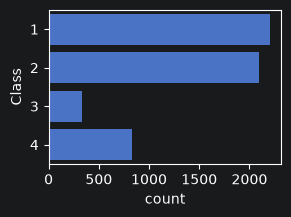

In [72]:
fig, ax = plt.subplots(figsize=(3, 2))
sns.countplot(data=y, ax=ax);

## EDA

In [210]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

### Train test split

In [204]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

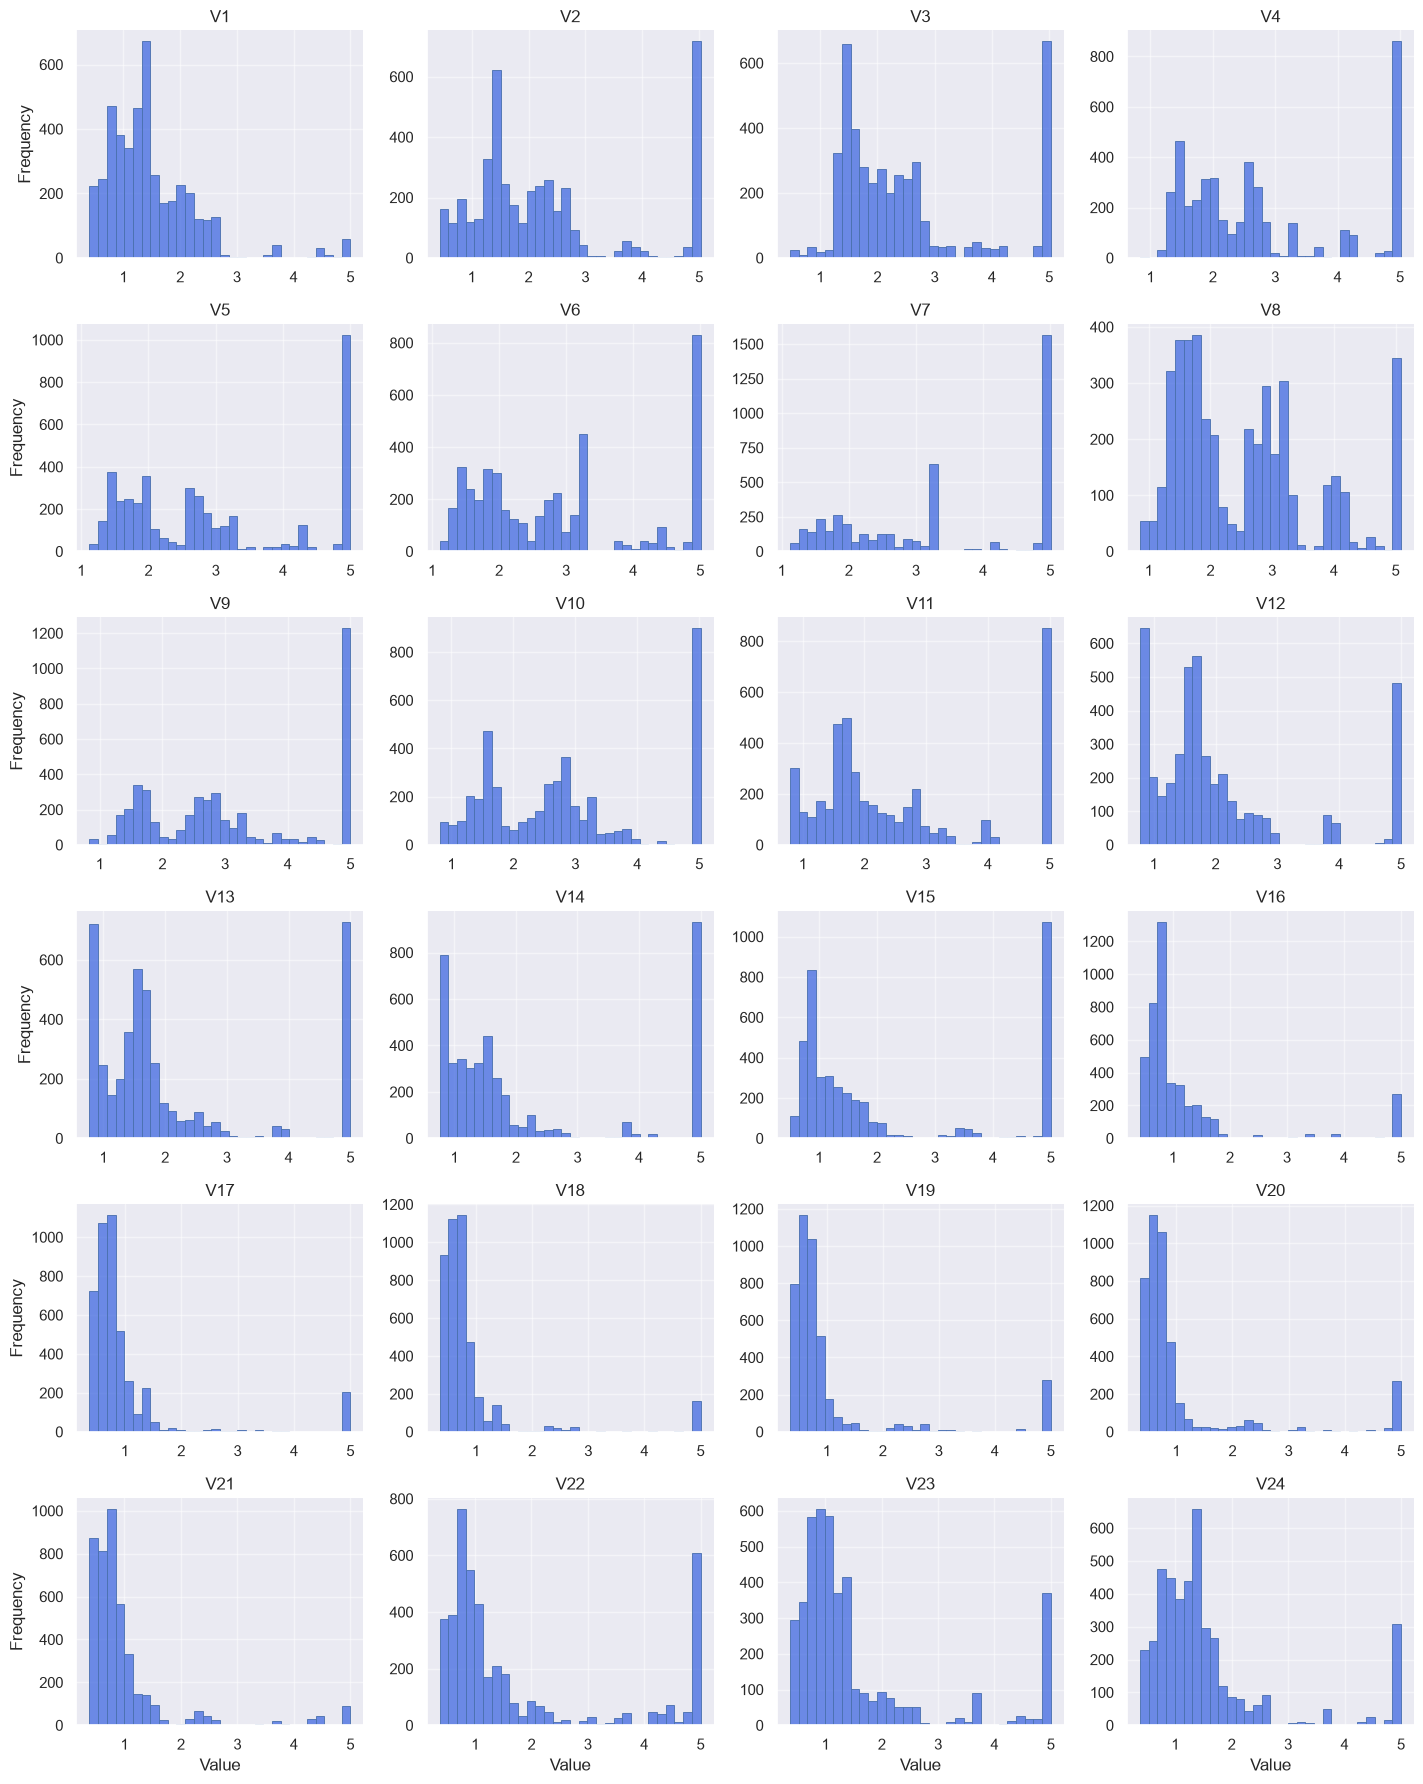

In [159]:
sns.set_theme(style="darkgrid")

X_train_melted = X_train.melt(var_name="Sensor", value_name="Value")

g = sns.FacetGrid(
    X_train_melted,
    col="Sensor",
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3,
    aspect=1.2,
)

g.map_dataframe(
    sns.histplot, x="Value", bins=30, color="royalblue", edgecolor="b"
)

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Frequency")

plt.tight_layout()
plt.show()

In [161]:
X.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


Not normal distribution, a lot of "5" value doe to sensor characteristics, many sensor correlations

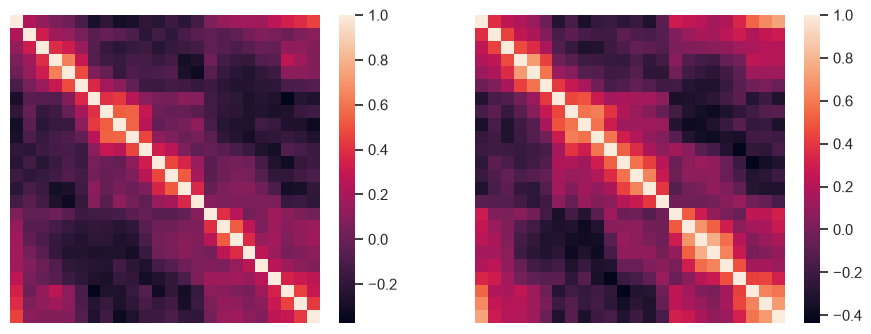

In [193]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11, 4))
sns.heatmap(X_train.corr(method='pearson', numeric_only=True),ax=ax1)
sns.heatmap(X_train.corr(method='spearman', numeric_only=True),ax=ax2)
ax1.set_xticks([]); ax1.set_yticks([])
ax2.set_xticks([]); ax2.set_yticks([])
plt.show()

In [203]:
import numpy as np
import pandas as pd


def remove_collinear_features(df, threshold=0.85):
    current_df = df.copy()
    while True:
        corr_matrix = current_df.corr(method="spearman").abs()

        mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        upper_tri = corr_matrix.where(mask)

        stacked_corr = upper_tri.unstack().dropna()
        high_corr = stacked_corr[stacked_corr > threshold]

        if len(high_corr) == 0:
            break

        high_corr = high_corr.sort_values(ascending=False)
        feat_A, feat_B = high_corr.index[0]

        mean_corr_A = corr_matrix[feat_A].mean()
        mean_corr_B = corr_matrix[feat_B].mean()

        to_drop = feat_A if mean_corr_A > mean_corr_B else feat_B
        current_df = current_df.drop(columns=[to_drop])

    return current_df


X_train_reduced = remove_collinear_features(X_train, threshold=0.50)
X_test_reduced = X_test[X_train_reduced.columns]
len(X_train_reduced.columns)

12

In [207]:
X_train_reduced.columns

Index(['V2', 'V3', 'V5', 'V7', 'V8', 'V12', 'V14', 'V15', 'V16', 'V20', 'V21',
       'V23'],
      dtype='str')

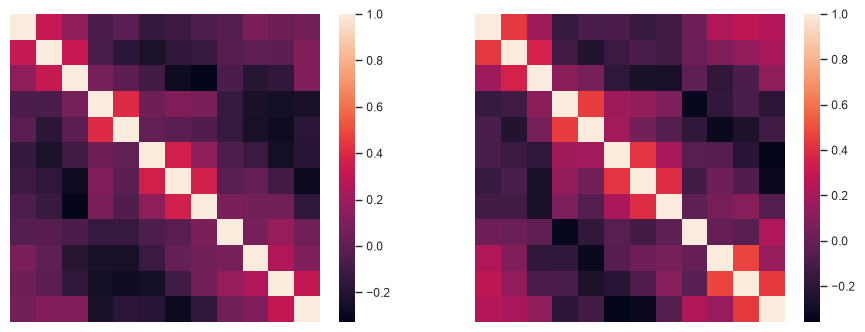

In [206]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11, 4))
sns.heatmap(X_train_reduced.corr(method='pearson', numeric_only=True),ax=ax1)
sns.heatmap(X_train_reduced.corr(method='spearman', numeric_only=True),ax=ax2)
ax1.set_xticks([]); ax1.set_yticks([])
ax2.set_xticks([]); ax2.set_yticks([])
plt.show()

### Scale data & encode y

In [209]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

In [213]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [222]:
print(type(X_test_scaled), type(y_train_encoded))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [226]:
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy',  X_test_scaled)
np.save('y_train_encoded.npy', y_train_encoded)
np.save('y_test_encoded.npy',  y_test_encoded)

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"Classes: {encoder.classes_}")

X_train: (4364, 12), X_test: (1092, 12)
Classes: ['1' '2' '3' '4']
